## Display of a subgraph of the real Google network with node labels

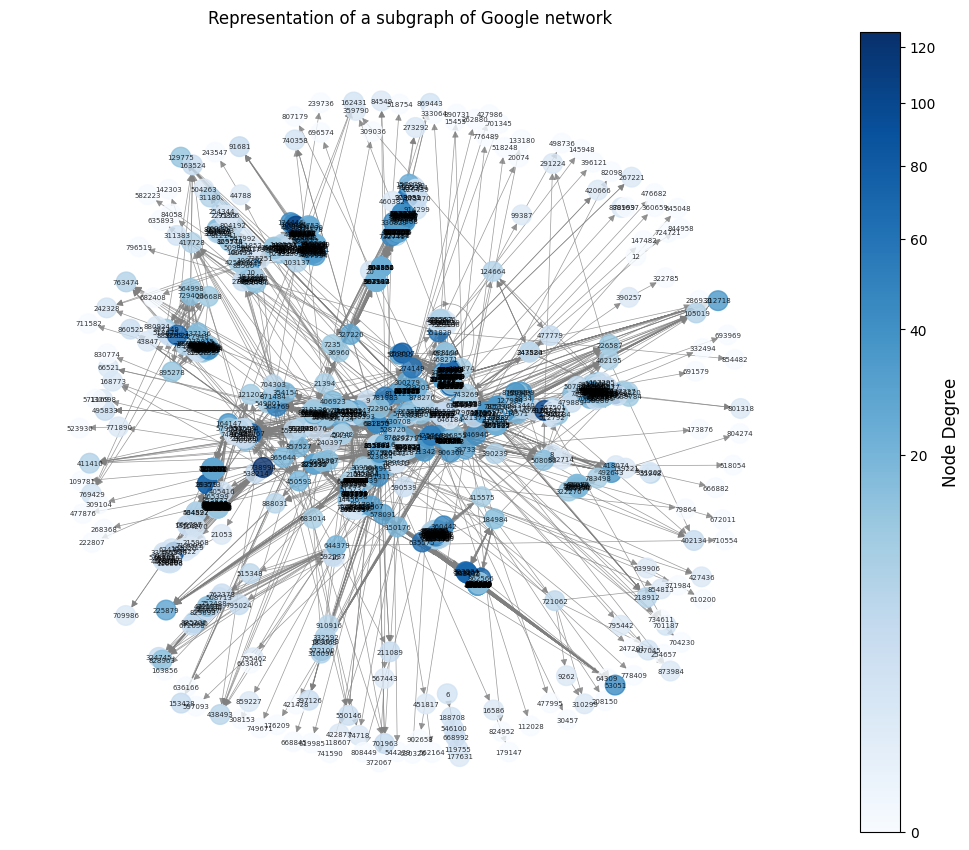

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# Load Google network
network = nx.read_edgelist("/content/drive/MyDrive/web-Google.txt.gz", create_using=nx.DiGraph, nodetype=int)

# Represent a subgraph of the Google network
plt.figure(figsize=(10, 8))
subset_nodes = list(network.nodes())[:1000]
subgraph = network.subgraph(subset_nodes)
pos = nx.spring_layout(subgraph)

# Color distribution based on node degree
node_degrees = [subgraph.degree(v) for v in subgraph.nodes()]
norm = PowerNorm(gamma=0.4, vmin=min(node_degrees), vmax=max(node_degrees))
node_colors = [plt.cm.Blues(norm(degree)) for degree in node_degrees]

nx.draw(subgraph, pos, node_size=200, font_size=5, node_color=node_colors, alpha=0.8, with_labels=True, edge_color='gray', width=0.5)

# Color bar
bar = plt.cm.ScalarMappable(cmap='Blues', norm=norm)
bar.set_array([])
cbar = plt.colorbar(bar, label='Node Degree', orientation='vertical', ax=plt.gca())
cbar.ax.yaxis.label.set_fontsize(12)

plt.title("Representation of a subgraph of the Google network")
plt.show()

## Display of a subgraph of the real Google network without node labels

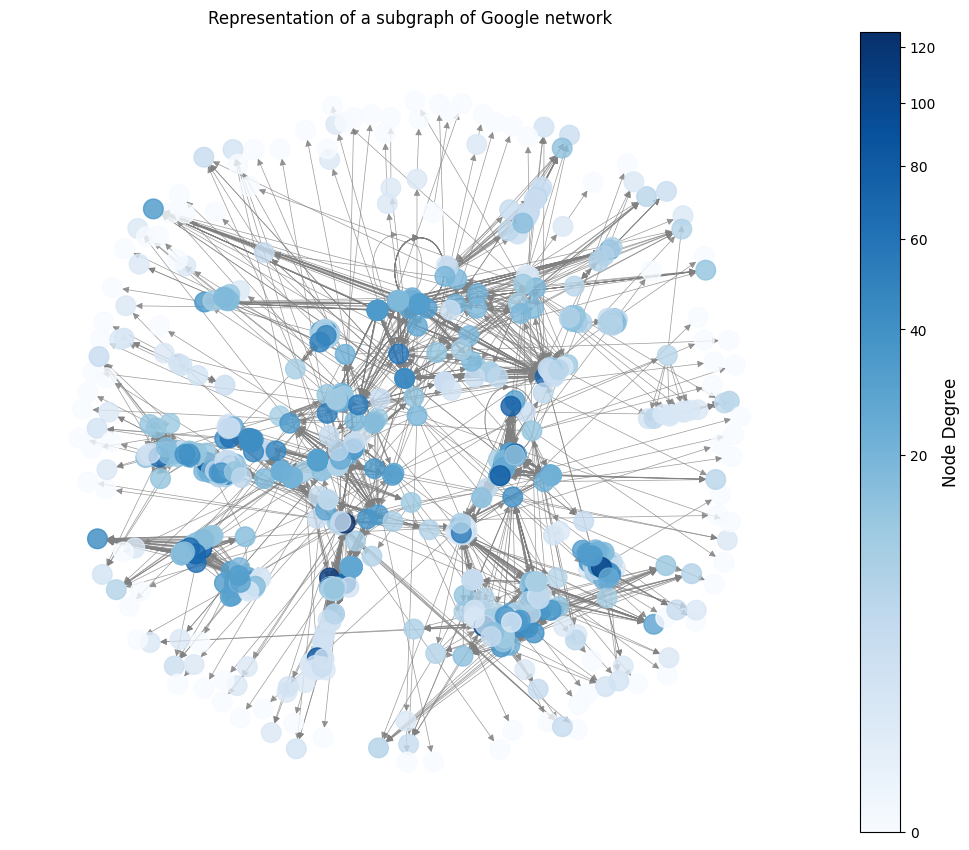

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# Load Google network
network = nx.read_edgelist("/content/drive/MyDrive/web-Google.txt.gz", create_using=nx.DiGraph, nodetype=int)

# Represent a subgraph of the Google network
plt.figure(figsize=(10, 8))
subset_nodes = list(network.nodes())[:1000]
subgraph = network.subgraph(subset_nodes)
pos = nx.spring_layout(subgraph)

# Color distribution based on node degree
node_degrees = [subgraph.degree(v) for v in subgraph.nodes()]
norm = PowerNorm(gamma=0.4, vmin=min(node_degrees), vmax=max(node_degrees))
node_colors = [plt.cm.Blues(norm(degree)) for degree in node_degrees]

nx.draw(subgraph, pos, node_size=200, font_size=5, node_color=node_colors, alpha=0.8, with_labels=False, edge_color='gray', width=0.5)

# Color bar
bar = plt.cm.ScalarMappable(cmap='Blues', norm=norm)
bar.set_array([])
cbar = plt.colorbar(bar, label='Node Degree', orientation='vertical', ax=plt.gca())
cbar.ax.yaxis.label.set_fontsize(12)

plt.title("Representation of a subgraph of the Google network")
plt.show()

## Define the PageRank algorithm and plot the convergence graph

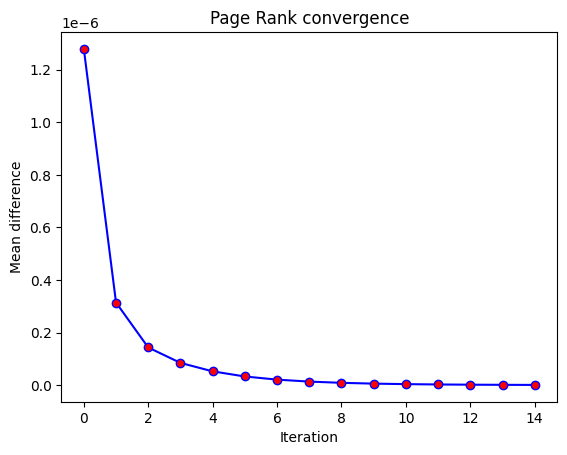

In [ ]:

# Define the PageRank function
def page_rank(network, alpha=0.85, max_iteration=20, threshold=1e-9):
  # Set the rank vector with the same value for all nodes
  n = len(network)
  rank = dict.fromkeys(network, 1.0 / n)

  # A list to store the mean difference of rank values in each iteration
  mean_diff = []

  # Continue until the maximum number of iterations or until the threshold is reached
  for i in range(max_iteration):
    rank_prev = rank.copy()
    # Update the rank vector for each node
    for u in network:
      rank[u] = (1 - alpha) / n + alpha * sum(rank[v] / len(network[v]) for v in network.predecessors(u))

    # Compute the mean difference of rank values between the current and previous iteration
    diff = sum(abs(rank[u] - rank_prev[u]) for u in network) / n
    mean_diff.append(diff)

    # Check the stop condition
    if diff < threshold:
      break

  # Return the final rank vector and the mean-difference list
  return rank, mean_diff

# Run the algorithm on the Google network
rank, mean_diff = page_rank(network)

# Plot the mean difference of rank values for each iteration
plt.plot(range(len(mean_diff)), mean_diff, marker='o', linestyle='-', color='blue', markerfacecolor='red')
plt.xlabel('Iteration')
plt.ylabel('Mean difference')
plt.title('PageRank convergence')
plt.show()

## Display the final ranking of the nodes

In [ ]:
# Display the ranking vector
print('Final ranking of nodes:')
counter = 1
for u, v in sorted(rank.items(), key=lambda x: x[1], reverse=True):
    print(f'{counter}. Node "{u}" --> Rank: {v}')
    counter += 1

Streaming output truncated to the last 5000 lines.
76271. Node"18528" --> Rank: 1.5121812330684687e-06
76272. Node"834254" --> Rank: 1.5121636150142475e-06
76273. Node"885335" --> Rank: 1.5121636150142475e-06
76274. Node"829611" --> Rank: 1.5121496487257878e-06
76275. Node"723298" --> Rank: 1.5121282620744704e-06
76276. Node"349767" --> Rank: 1.5121151986796696e-06
76277. Node"559663" --> Rank: 1.5120627181317606e-06
76278. Node"418300" --> Rank: 1.5120354911907575e-06
76279. Node"443857" --> Rank: 1.5120322627375518e-06
76280. Node"490043" --> Rank: 1.5120033797820437e-06
76281. Node"906636" --> Rank: 1.5119852901761107e-06
76282. Node"685746" --> Rank: 1.5119494420013733e-06
76283. Node"752507" --> Rank: 1.5119418915665362e-06
76284. Node"760926" --> Rank: 1.511940842170149e-06
76285. Node"855958" --> Rank: 1.511935848783054e-06
76286. Node"201300" --> Rank: 1.511934020259494e-06
76287. Node"845182" --> Rank: 1.511929520119345e-06
76288. Node"763309" --> Rank: 1.5119105029270848e-06


IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



Streaming output truncated to the last 5000 lines.
141204. Node"746740" --> Rank: 9.362369812803095e-07
141205. Node"462640" --> Rank: 9.362194482130669e-07
141206. Node"123235" --> Rank: 9.362174784636375e-07
141207. Node"194720" --> Rank: 9.36217055004747e-07
141208. Node"375267" --> Rank: 9.362119725912659e-07
141209. Node"746102" --> Rank: 9.362113821976481e-07
141210. Node"351749" --> Rank: 9.36210719562131e-07
141211. Node"715070" --> Rank: 9.362092369488922e-07
141212. Node"836395" --> Rank: 9.361976088898261e-07
141213. Node"691509" --> Rank: 9.36187989412677e-07
141214. Node"767192" --> Rank: 9.361819994209212e-07
141215. Node"898839" --> Rank: 9.361803321392782e-07
141216. Node"229949" --> Rank: 9.361785733375554e-07
141217. Node"166719" --> Rank: 9.361749090148108e-07
141218. Node"315492" --> Rank: 9.361749090148108e-07
141219. Node"632677" --> Rank: 9.361749090148108e-07
141220. Node"794759" --> Rank: 9.361749090148108e-07
141221. Node"747775" --> Rank: 9.361642928245408e-0

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



Streaming output truncated to the last 5000 lines.
315314. Node"52290" --> Rank: 4.225116815351135e-07
315315. Node"106755" --> Rank: 4.2251107378895753e-07
315316. Node"770683" --> Rank: 4.2251074724403713e-07
315317. Node"681574" --> Rank: 4.2250983256799733e-07
315318. Node"664018" --> Rank: 4.225096930935684e-07
315319. Node"782993" --> Rank: 4.225093550224681e-07
315320. Node"770510" --> Rank: 4.2250765729593337e-07
315321. Node"870545" --> Rank: 4.2250465687732934e-07
315322. Node"854902" --> Rank: 4.2250132196240726e-07
315323. Node"652578" --> Rank: 4.2249684338334886e-07
315324. Node"869685" --> Rank: 4.2249684338334886e-07
315325. Node"252183" --> Rank: 4.224926251042998e-07
315326. Node"110966" --> Rank: 4.224885039659252e-07
315327. Node"178094" --> Rank: 4.2248726742846786e-07
315328. Node"243781" --> Rank: 4.2248726742846786e-07
315329. Node"389867" --> Rank: 4.2248726742846786e-07
315330. Node"506048" --> Rank: 4.2248726742846786e-07
315331. Node"686210" --> Rank: 4.2248

...

Streaming output truncated to the last 5000 lines.
519391. Node"32791" --> Rank: 2.4301691461662536e-07
519392. Node"536683" --> Rank: 2.4301691461662536e-07
519393. Node"815562" --> Rank: 2.4301691461662536e-07
519394. Node"436435" --> Rank: 2.4301691461662536e-07
519395. Node"865397" --> Rank: 2.4301691461662536e-07
519396. Node"553236" --> Rank: 2.430151681478108e-07
519397. Node"220458" --> Rank: 2.4301509477364507e-07
519398. Node"800963" --> Rank: 2.430144056228397e-07
519399. Node"603733" --> Rank: 2.4301385101420336e-07
519400. Node"830531" --> Rank: 2.4301366351443736e-07
519401. Node"393096" --> Rank: 2.430136608992822e-07
519402. Node"724703" --> Rank: 2.430136608992822e-07
519403. Node"735085" --> Rank: 2.430136608992822e-07
519404. Node"556159" --> Rank: 2.4301360760389644e-07
519405. Node"392646" --> Rank: 2.430129371200633e-07
519406. Node"491530" --> Rank: 2.430129371200633e-07
519407. Node"365934" --> Rank: 2.4301002635019645e-07
519408. Node"467748" --> Rank: 2.430100

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



Streaming output truncated to the last 5000 lines.
754989. Node"200130" --> Rank: 1.7128899536720366e-07
754990. Node"200131" --> Rank: 1.7128899536720366e-07
754991. Node"200134" --> Rank: 1.7128899536720366e-07
754992. Node"200137" --> Rank: 1.7128899536720366e-07
754993. Node"200146" --> Rank: 1.7128899536720366e-07
754994. Node"200147" --> Rank: 1.7128899536720366e-07
754995. Node"200153" --> Rank: 1.7128899536720366e-07
754996. Node"200157" --> Rank: 1.7128899536720366e-07
754997. Node"200159" --> Rank: 1.7128899536720366e-07
754998. Node"200161" --> Rank: 1.7128899536720366e-07
754999. Node"200164" --> Rank: 1.7128899536720366e-07
755000. Node"200168" --> Rank: 1.7128899536720366e-07
755001. Node"200172" --> Rank: 1.7128899536720366e-07
755002. Node"200174" --> Rank: 1.7128899536720366e-07
755003. Node"200176" --> Rank: 1.7128899536720366e-07
755004. Node"200180" --> Rank: 1.7128899536720366e-07
755005. Node"200190" --> Rank: 1.7128899536720366e-07
755006. Node"200193" --> Rank: 

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



Streaming output truncated to the last 5000 lines.
870714. Node"862774" --> Rank: 1.7128899536720366e-07
870715. Node"862776" --> Rank: 1.7128899536720366e-07
870716. Node"862795" --> Rank: 1.7128899536720366e-07
870717. Node"862815" --> Rank: 1.7128899536720366e-07
870718. Node"862820" --> Rank: 1.7128899536720366e-07
870719. Node"862822" --> Rank: 1.7128899536720366e-07
870720. Node"862831" --> Rank: 1.7128899536720366e-07
870721. Node"862840" --> Rank: 1.7128899536720366e-07
870722. Node"862841" --> Rank: 1.7128899536720366e-07
870723. Node"862845" --> Rank: 1.7128899536720366e-07
870724. Node"862846" --> Rank: 1.7128899536720366e-07
870725. Node"862852" --> Rank: 1.7128899536720366e-07
870726. Node"862863" --> Rank: 1.7128899536720366e-07
870727. Node"862870" --> Rank: 1.7128899536720366e-07
870728. Node"862894" --> Rank: 1.7128899536720366e-07
870729. Node"862897" --> Rank: 1.7128899536720366e-07
870730. Node"862912" --> Rank: 1.7128899536720366e-07
870731. Node"862922" --> Rank: 